In [309]:
from tqdm import tqdm

import networkx as nx
import pandas as pd
import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from helpers import read_ka2_graphml, digraph_config_model, language_similarity, weight_attribute_mixing_matrix, obs_config_attribute_mixmat

## Load the network

In [339]:
G = read_ka2_graph(years=np.arange(2017, 2020, 1), graph_dir='../data/ka2_graphs/', fname_prefix='ka2_mobility_network_org_')

Y2017-2018-2019 graph has 14203 nodes and 42767 directed, weighted edges. 
The total number of participants is 283813.


### Metadata

In [340]:
def get_node_metadata(G, meta_df):
    country = nx.get_node_attributes(G, 'country')
    lang = dict(map(lambda x: (x[0], 
                               df.loc[x[1]]['Language_Family']), 
                    country.items()
                   )
               )
    culture =  dict(map(lambda x: (x[0], 
                               df.loc[x[1]]['Geographical_Cultural_Region']), 
                    country.items()
                   )
               )
    econ = dict(map(lambda x: (x[0], 
                               df.loc[x[1]]['Economic_Family']), 
                    country.items()
                   )
               )
    return lang, culture, econ

In [341]:
df = pd.read_csv('../data/country_extra_data.csv').set_index('Country')
lang, culture, econ = get_node_metadata(G, df)

### Visualize

In [342]:
%%time
pos=nx.spring_layout(G, seed=42)

CPU times: user 5min 48s, sys: 24.9 ms, total: 5min 48s
Wall time: 5min 32s


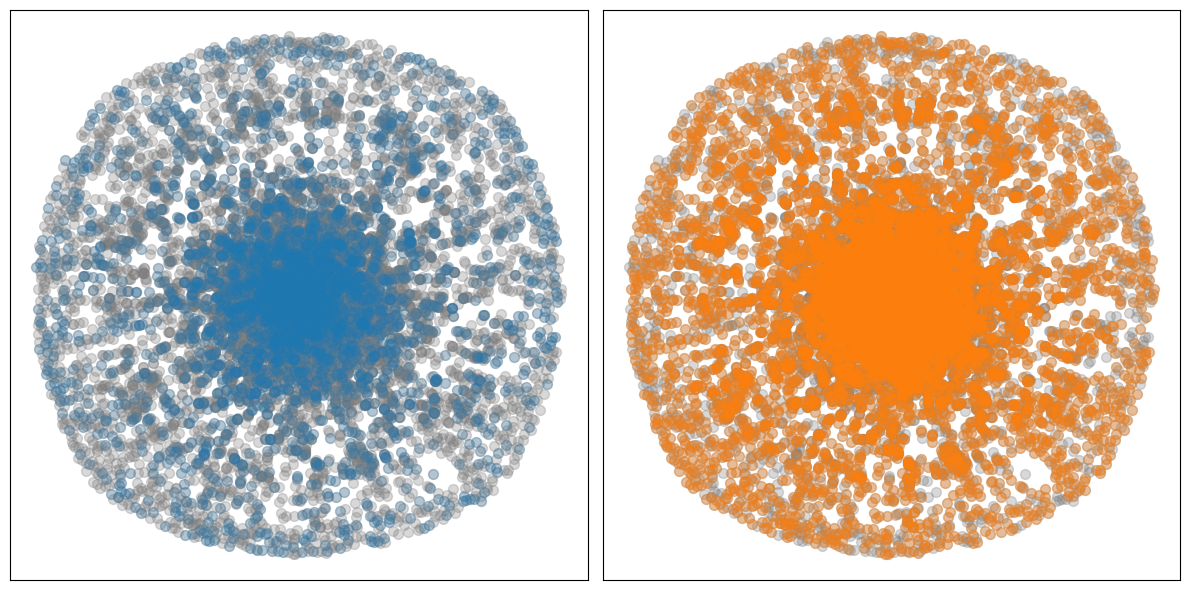

In [343]:
tableau = mpl.colors.TABLEAU_COLORS
fig, axs = plt.subplots(1, 2, figsize=(12,6))

nx.draw_networkx_nodes(G, pos=pos,  
                       node_color=tableau['tab:gray'], alpha=.3, node_size=50, ax=axs[0])
nx.draw_networkx_nodes(G, pos=pos, 
                       nodelist=[n for n in G if econ.get(n)=='Emerging_Market'], 
                       node_color=tableau['tab:blue'], alpha=.2, node_size=50, ax=axs[0])

nx.draw_networkx_nodes(G, pos=pos,  
                       node_color=tableau['tab:gray'], alpha=.3, node_size=50, ax=axs[1])
nx.draw_networkx_nodes(G, pos=pos, 
                       nodelist=[n for n in G if econ.get(n)=='Advanced_Economy'], 
                       node_color=tableau['tab:orange'], alpha=.3, node_size=50, ax=axs[1])
plt.tight_layout()
plt.show()

### Configuration Model

In [350]:
randG = digraph_config_model(G, weight='weight')

(array([1.3915e+04, 1.6300e+02, 6.4000e+01, 3.4000e+01, 2.0000e+00,
        1.7000e+01, 3.0000e+00, 0.0000e+00, 0.0000e+00, 5.0000e+00]),
 array([0.        , 0.01666667, 0.03333333, 0.05      , 0.06666667,
        0.08333333, 0.1       , 0.11666667, 0.13333333, 0.15      ,
        0.16666667]),
 <BarContainer object of 10 artists>)

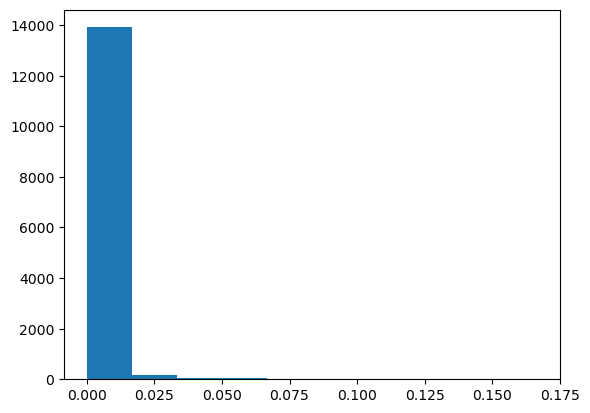

In [351]:
cluster_coef = nx.clustering(randG, weight="weight")
plt.hist(cluster_coef.values())

In [352]:
core = max(nx.weakly_connected_components(randG), key=len)
core = randG.subgraph(core)
print(f'The graph has a giant component with {core.number_of_nodes()} nodes and {core.number_of_edges()} {directed}, {weighted} edges.')

The graph has a giant component with 14203 nodes and 283075 directed, weighted edges.


## Properties

### Degree sequence

In [344]:
in_degrees = dict(G.in_degree())
out_degrees = dict(G.out_degree())
weights = nx.get_edge_attributes(G, name="weight")

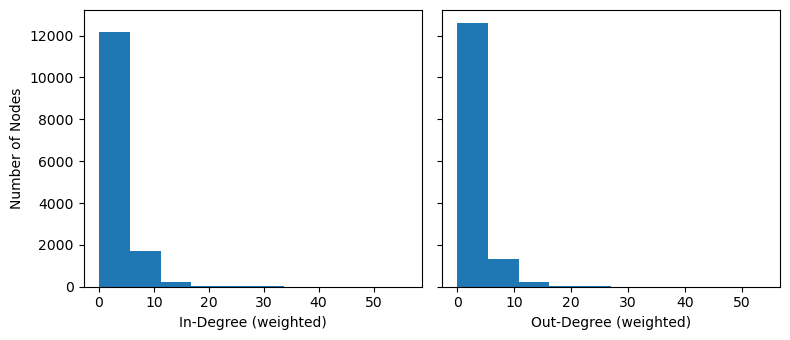

In [345]:
fig, axs = plt.subplots(1, 2, figsize=(8, 3.5), sharey=True)
axs[0].hist(in_degrees.values())
axs[1].hist(out_degrees.values())
axs[0].set_ylabel("Number of Nodes")
axs[0].set_xlabel("In-Degree (weighted)")
axs[1].set_xlabel("Out-Degree (weighted)")
plt.tight_layout()
plt.show()

(array([3.8418e+04, 3.5360e+03, 5.7500e+02, 1.5700e+02, 4.9000e+01,
        2.5000e+01, 4.0000e+00, 2.0000e+00, 0.0000e+00, 1.0000e+00]),
 array([ 1. , 10.2, 19.4, 28.6, 37.8, 47. , 56.2, 65.4, 74.6, 83.8, 93. ]),
 <BarContainer object of 10 artists>)

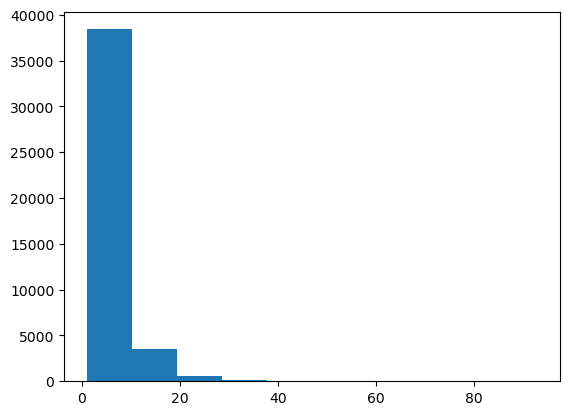

In [346]:
plt.hist(weights.values())

Degrees follow a long-tail distribution with high heterogenity, similar to edge weights.

### Clustering

In [347]:
cluster_coef = nx.clustering(G, weight="weight")

(array([8.325e+03, 3.884e+03, 1.426e+03, 3.410e+02, 1.320e+02, 5.700e+01,
        1.900e+01, 9.000e+00, 8.000e+00, 2.000e+00]),
 array([0.        , 0.03297265, 0.0659453 , 0.09891796, 0.13189061,
        0.16486326, 0.19783591, 0.23080856, 0.26378122, 0.29675387,
        0.32972652]),
 <BarContainer object of 10 artists>)

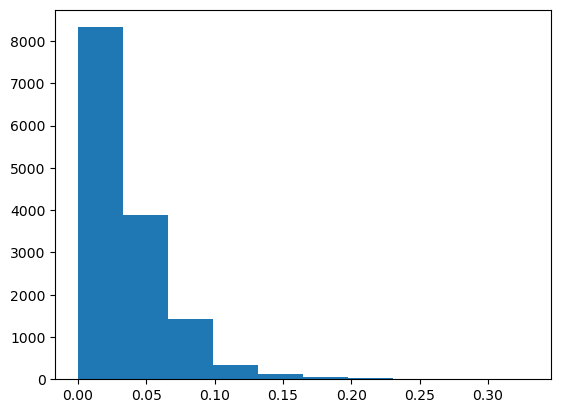

In [348]:
plt.hist(cluster_coef.values())

### Core-periphery

In [349]:
core = max(nx.weakly_connected_components(G), key=len)
core = G.subgraph(core)
print(f'Y{year} graph has a giant component with {core.number_of_nodes()} nodes and {core.number_of_edges()} {directed}, {weighted} edges.')

Y2016 graph has a giant component with 11074 nodes and 37155 directed, weighted edges.


### Attribute Assortativity (Homophily)

To assess assortativity with relation to nodal attributes, one can observe the number of same attribute edges and cross-attribute edges.

In [337]:
lang_edgetypes = {}

for s, t, w in G.edges(data="weight"):
    
    langsim = language_similarity(lang[s], lang[t])
    
    if langsim in lang_edgetypes:
        lang_edgetypes[langsim]["pair"] += 1
        lang_edgetypes[langsim]["weighted"] += w
    else:
        lang_edgetypes[langsim]={"pair": 1,
                                 "weighted": w
                                }

<Axes: xlabel='langsim', ylabel='count'>

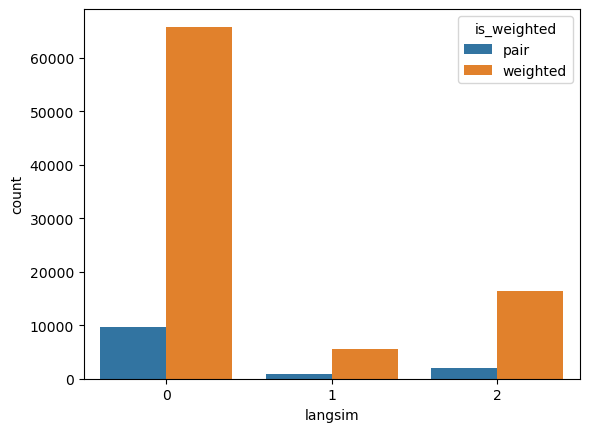

In [338]:
plot_data = pd.DataFrame(lang_edgetypes).T.reset_index(names='langsim')
plot_data = plot_data.melt(id_vars='langsim', value_vars=['pair', 'weighted'], var_name='is_weighted', value_name='count')
sns.barplot(plot_data, x='langsim', y='count', hue='is_weighted')

When there are a small number of node categories, attribute mixing matrix can be useful in identifying assortativity. We use this approach to investigate homophily with respect to geo-cultural factors.

In [317]:
nx.set_node_attributes(G, culture, name='culture')
mapping = {l:ind for ind, l in enumerate(sorted(set(culture.values())))}
mat = nx.attribute_mixing_matrix(G, attribute='culture', mapping=mapping)
wmat = weight_attribute_mixing_matrix(G, attribute='culture', mapping=mapping)

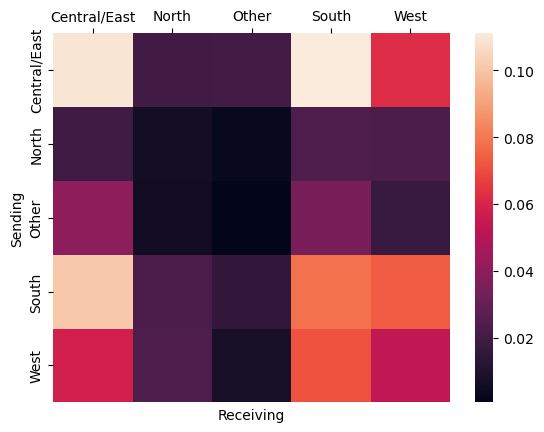

In [318]:
df_heat = pd.DataFrame(mat, columns=mapping.keys(), index=mapping.keys())
sns.heatmap(df_heat)
plt.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
plt.xlabel('Receiving')
plt.ylabel('Sending')
plt.show()

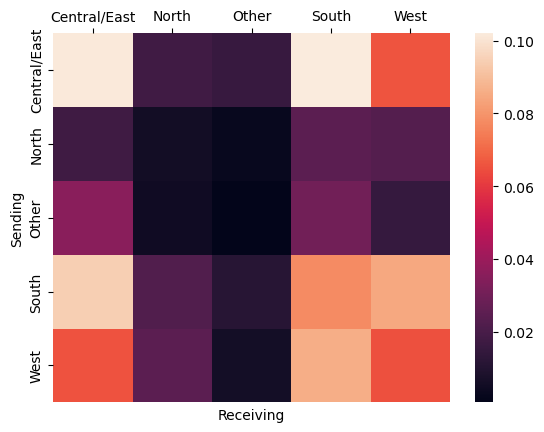

In [320]:
df_heat = pd.DataFrame(wmat, columns=mapping.keys(), index=mapping.keys())
sns.heatmap(df_heat)
plt.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
plt.xlabel('Receiving')
plt.ylabel('Sending')
plt.show()

The proprotions of different edge types show more intensive mobility within the Central/Eastern Europe block and moderately strong mobility within Southern Europe and Western Europe. However, due to highly heterogenous degrees, the frequency and scale of mobility each block can have are different, cofounding with homophily. 

Below, we do degree-corrections using the configuration network model to disentangle this cofounder.

In [322]:
relattribute_mixmat, lower, upper =  obs_config_attribute_mixmat(G, attribute='culture', mapping=mapping)
relattribute_wmixmat, wlower, wupper =  obs_config_attribute_mixmat(G, attribute='culture', weight='weight', mapping=mapping)

100%|██████████| 50/50 [00:25<00:00,  1.92it/s]


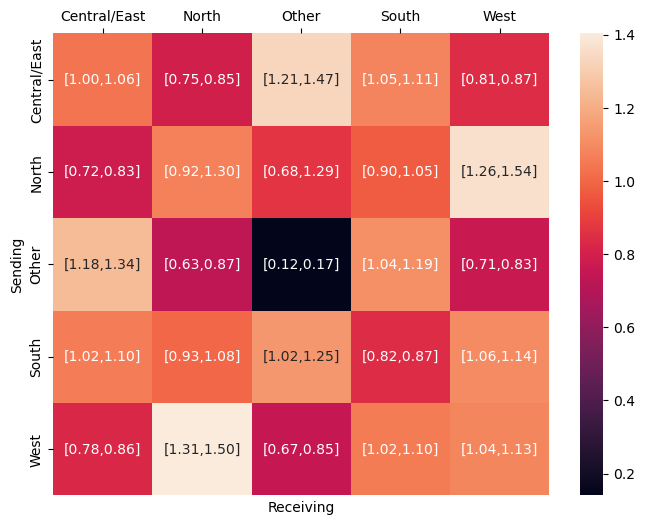

In [323]:
lower_mat = np.char.mod('%.2f', lower)
upper_mat = np.char.mod('%.2f', upper)
labels = [
        [f"[{item1},{item2}]" for item1, item2 in zip(row1, row2)]
        for row1, row2 in zip(lower_mat, upper_mat)
        ]
df_heat = pd.DataFrame(relattribute_mixmat, columns=mapping.keys(), index=mapping.keys())
plt.figure(figsize=(8,6))
sns.heatmap(df_heat, annot=labels, fmt='')
plt.xlabel('Receiving')
plt.ylabel('Sending')
plt.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
plt.show()

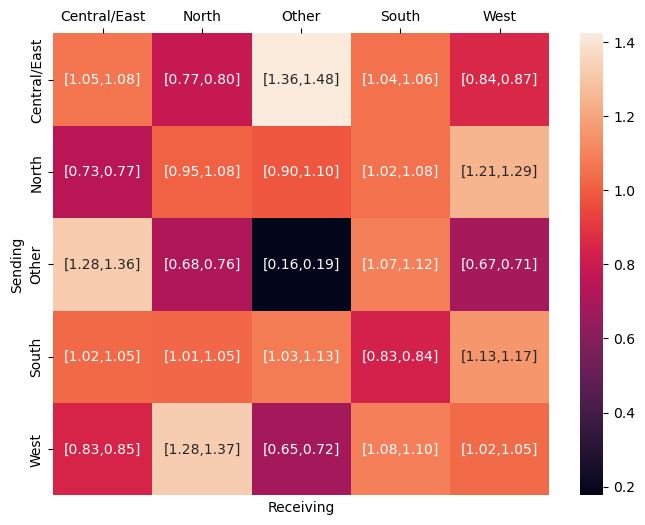

In [324]:
lower_mat = np.char.mod('%.2f', wlower)
upper_mat = np.char.mod('%.2f', wupper)
labels = [
        [f"[{item1},{item2}]" for item1, item2 in zip(row1, row2)]
        for row1, row2 in zip(lower_mat, upper_mat)
        ]

df_heat = pd.DataFrame(relattribute_wmixmat, columns=mapping.keys(), index=mapping.keys())
plt.figure(figsize=(8,6))
sns.heatmap(df_heat, annot=labels, fmt='')
plt.xlabel('Receiving')
plt.ylabel('Sending')
plt.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
plt.show()

Degree correction uncovers some disassortative patterns, particularly mobility between near Europe countries and Eastern/Southern Europe, and that between Northern and Western Europe. 

### Attribute Disassortivity (Core-periphery)

Similarly, mobility patterns between advanced economy and emerging market can be observed with atrribute mixing matrices. Before degree-correction, it seems that there's a core-periphery structure (consistent with the network visualization), particularly with relation to country economic status.

In [325]:
nx.set_node_attributes(G, econ, name='econ')
mapping = {l:ind for ind, l in enumerate(sorted(set(econ.values())))}
mat = nx.attribute_mixing_matrix(G, attribute='econ', mapping=mapping)
wmat = weight_attribute_mixing_matrix(G, attribute='econ', mapping=mapping)

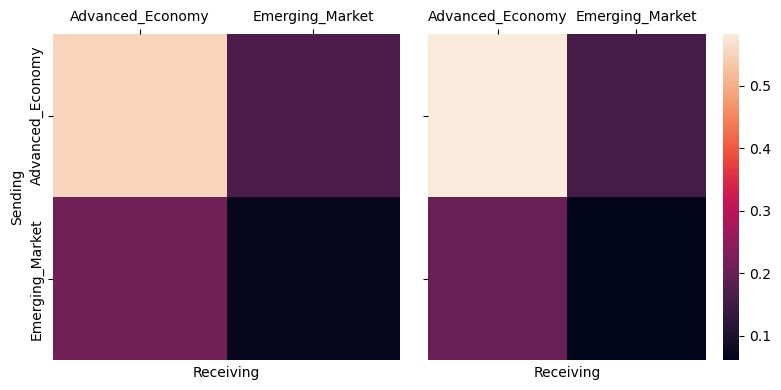

In [330]:
fig, axs = plt.subplots(1, 2, figsize=(8,4), sharey=True)
vmin = np.min([mat, wmat])
vmax = np.max([mat, wmat])

# non weighted (% cross-organization mobility)
df_heat = pd.DataFrame(mat, columns=mapping.keys(), index=mapping.keys())
sns.heatmap(df_heat, ax=axs[0], vmin=vmin, vmax=vmax, cbar=False)
axs[0].tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
axs[0].set_xlabel('Receiving')
axs[0].set_ylabel('Sending')

# weighted (% participants)
df_heat = pd.DataFrame(wmat, columns=mapping.keys(), index=mapping.keys())
sns.heatmap(df_heat, ax=axs[1], vmin=vmin, vmax=vmax, cbar=True)
axs[1].tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
axs[1].set_xlabel('Receiving')
plt.tight_layout()
plt.show()

In [331]:
relattribute_mixmat, lower, upper =  obs_config_attribute_mixmat(G, attribute='econ', mapping=mapping)
relattribute_wmixmat, wlower, wupper =  obs_config_attribute_mixmat(G, attribute='econ', weight='weight', mapping=mapping)

100%|██████████| 50/50 [00:25<00:00,  1.93it/s]


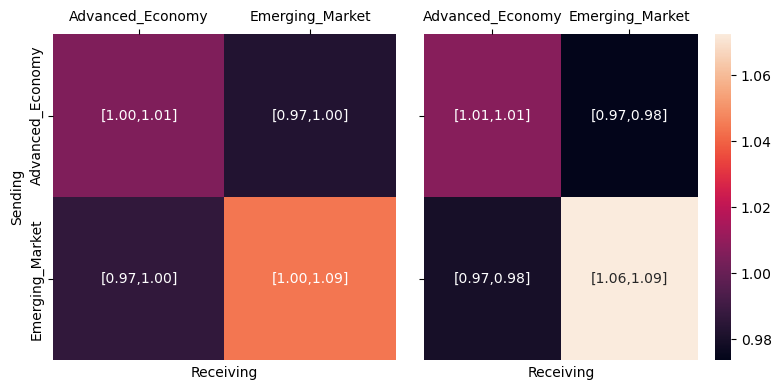

In [336]:
fig, axs = plt.subplots(1, 2, figsize=(8,4), sharey=True)
vmin = np.min([relattribute_mixmat, relattribute_wmixmat])
vmax = np.max([relattribute_mixmat, relattribute_wmixmat])

# non weighted (% cross-organization mobility - obs/config) 
lower_mat = np.char.mod('%.2f', lower)
upper_mat = np.char.mod('%.2f', upper)
labels = [
        [f"[{item1},{item2}]" for item1, item2 in zip(row1, row2)]
        for row1, row2 in zip(lower_mat, upper_mat)
        ]
df_heat = pd.DataFrame(relattribute_mixmat, columns=mapping.keys(), index=mapping.keys())
sns.heatmap(df_heat, ax=axs[0], vmin=vmin, vmax=vmax, cbar=False, annot=labels, fmt='')
axs[0].tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
axs[0].set_xlabel('Receiving')
axs[0].set_ylabel('Sending')

# weighted (% participants - obs/config)
lower_mat = np.char.mod('%.2f', wlower)
upper_mat = np.char.mod('%.2f', wupper)
labels = [
        [f"[{item1},{item2}]" for item1, item2 in zip(row1, row2)]
        for row1, row2 in zip(lower_mat, upper_mat)
        ]

df_heat = pd.DataFrame(relattribute_wmixmat, columns=mapping.keys(), index=mapping.keys())
sns.heatmap(df_heat, ax=axs[1], vmin=vmin, vmax=vmax, annot=labels, fmt='')
axs[1].tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
axs[1].set_xlabel('Receiving')
# axs[1].set_ylabel('Sending')

plt.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
plt.tight_layout()
plt.show()

After degree-correction, we can see that advanced economies show up more in the core most likely due to their large-scale and frequent mobility compared to the emergent markets and not bias preferences.  